# Levitation model: graphite disk on cylinder+ring magnet trap

Independent model of the diamagnetic trap (parallels Dave's COMSOL `cyl_rotor_3d.mph`,
but uses **exact analytic magnet fields** via `magpylib` -- permanent magnets in vacuum
need no FEM). Energy method, same as the COMSOL writeup:

U = -(1/2mu0) Int[ chi_perp(Bx^2+By^2) + chi_z Bz^2 ] dV + m g z_com

**Magnets** (K&J specs): inner DH12 cylinder d=2.54 mm, h=3.17 mm, N42 (Br=1.32 T), pole up;
ring R422CS-S-N52, OD 6.35 / ID 2.72 / h 3.17 mm, N52 (Br=1.48 T), pole down; tops flush.
Countersink NOT modeled (straight bore) -- geometry knob to refine.

**Graphite**: chi = (-85, -85, -450)e-6 (SI, c-axis vertical), rho = 2200 kg/m^3.

Key physics: both lift and weight are body forces ~ volume, so U/V sets the equilibrium
-- levitation height is independent of disk size/mass for a homogeneous disk
(magnetic buoyancy). Size enters only through (a) volume-averaging of the field
(weak height dependence) and (b) lateral stability (strong: disk must straddle the
inner-magnet/ring flux boundary).

In [1]:
import numpy as np, magpylib as magpy, matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

MU0 = 4e-7*np.pi; G = 9.81
CHI_PERP, CHI_Z = -85e-6, -450e-6
RHO = 2200.0
H = 3.17e-3

def build_field(br_in=1.32, br_out=1.48, z_inner_offset=0.0):
    """Axisymmetric field grid; z=0 at magnet top faces. z_inner_offset shifts inner magnet."""
    inner = magpy.magnet.Cylinder(polarization=(0,0,br_in), dimension=(2.54e-3,H),
                                  position=(0,0,-H/2+z_inner_offset))
    ring  = magpy.magnet.CylinderSegment(polarization=(0,0,-br_out),
                                         dimension=(2.72e-3/2,6.35e-3/2,H,0,360), position=(0,0,-H/2))
    col = magpy.Collection(inner, ring)
    rg = np.linspace(0, 4.5e-3, 200); zg = np.linspace(0.02e-3, 2.5e-3, 140)
    RR, ZZ = np.meshgrid(rg, zg, indexing='ij')
    B = col.getB(np.column_stack([RR.ravel(), np.zeros(RR.size), ZZ.ravel()]))
    Br = RegularGridInterpolator((rg,zg), B[:,0].reshape(RR.shape), bounds_error=False, fill_value=None)
    Bz = RegularGridInterpolator((rg,zg), B[:,2].reshape(RR.shape), bounds_error=False, fill_value=None)
    return Br, Bz

BR, BZ = build_field()

In [2]:
def disk_samples(d, t, nr=10, nphi=16, nz=5):
    rj = d/2*np.sqrt((np.arange(nr)+0.5)/nr)          # equal-area radii
    ph = np.linspace(0, 2*np.pi, nphi, endpoint=False)
    zk = (np.arange(nz)+0.5)/nz*t - t/2
    R,P,Z = np.meshgrid(rj,ph,zk, indexing='ij')
    return R.ravel()*np.cos(P.ravel()), R.ravel()*np.sin(P.ravel()), Z.ravel()

def u_vol(rc, zc, d, t, Br=None, Bz=None, chi_z=CHI_Z, rho=RHO, extra_m_frac=0.0):
    """Potential per unit disk volume [J/m^3], disk center at (rc, zc).
    extra_m_frac: dead mass (wings/tape) as fraction of disk mass -- adds weight, no chi."""
    Br = Br or BR; Bz = Bz or BZ
    xs, ys, zs = disk_samples(d, t)
    r = np.hypot(xs+rc, ys); z = zs+zc
    br = Br(np.column_stack([r,z])); bz = Bz(np.column_stack([r,z]))
    return -np.mean(CHI_PERP*br**2 + chi_z*bz**2)/(2*MU0) + rho*(1+extra_m_frac)*G*zc

def z_eq(d, t, **kw):
    zc = np.linspace(t/2+0.02e-3, 2.0e-3, 140)
    U = np.array([u_vol(0, z, d, t, **kw) for z in zc])
    i = int(np.argmin(U))
    return (zc[i] if 0 < i < len(zc)-1 else np.nan), zc, U

def lateral_stiffness(d, t, zeq, **kw):
    rc = np.linspace(0, 0.4e-3, 9)
    U = np.array([u_vol(r, zeq, d, t, **kw) for r in rc])
    k = np.polyfit(rc, U, 2)[0]*2      # d2(U/V)/dr2  [J/m^3/m^2]
    return k

In [3]:
t = 0.5e-3
print("d [mm]   z_com [mm]  gap [mm]   lateral        f_z [Hz]  f_r [Hz]")
for d_mm in (2.0, 2.5, 3.0, 3.5, 4.0):
    d = d_mm*1e-3
    ze, zc, U = z_eq(d, t)
    if np.isnan(ze):
        print(f"{d_mm:5.1f}    -- no vertical equilibrium --"); continue
    kr = lateral_stiffness(d, t, ze)
    kz = np.polyfit(zc[abs(zc-ze)<0.15e-3], U[abs(zc-ze)<0.15e-3], 2)[0]*2
    fz = np.sqrt(max(kz,0)/RHO)/(2*np.pi); fr = np.sqrt(max(kr,0)/RHO)/(2*np.pi)
    print(f"{d_mm:5.1f}    {ze*1e3:8.3f}   {(ze-t/2)*1e3:7.3f}   "
          f"{'STABLE  ' if kr>0 else 'UNSTABLE'}   {fz:7.1f}   {fr:7.1f}")

ze,_,_ = z_eq(2.9e-3, 0.6e-3)
print(f"\nValidation (photo disk d=2.9, t=0.6): gap = {(ze-0.3e-3)*1e3:.2f} mm  (measured ~0.5 mm)")

d [mm]   z_com [mm]  gap [mm]   lateral        f_z [Hz]  f_r [Hz]
  2.0       0.830     0.580   UNSTABLE      33.7       0.0
  2.5       0.755     0.505   STABLE        34.6       8.4
  3.0       0.706     0.456   STABLE        34.1      11.7
  3.5       0.706     0.456   STABLE        32.8      11.1
  4.0       0.731     0.481   STABLE        30.9       8.0

Validation (photo disk d=2.9, t=0.6): gap = 0.43 mm  (measured ~0.5 mm)


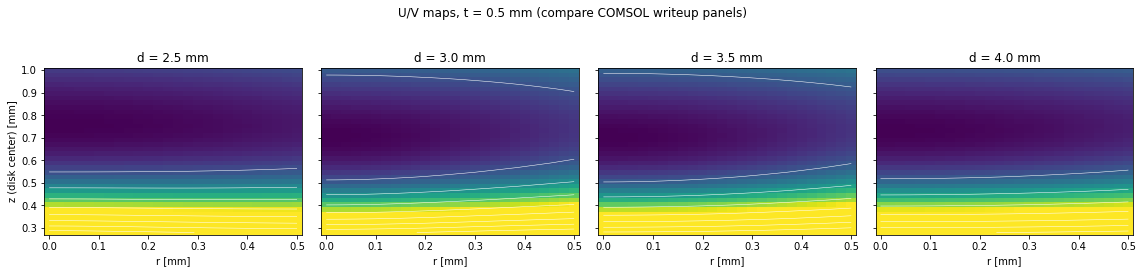

In [4]:
# U(r,z) maps, same layout as the COMSOL writeup (t = 0.5 mm)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
rcs = np.linspace(0, 0.5e-3, 26); zcs = np.linspace(0.28e-3, 1.0e-3, 36)
for ax, d_mm in zip(axes, (2.5, 3.0, 3.5, 4.0)):
    d = d_mm*1e-3
    Umap = np.array([[u_vol(r, z, d, t) for z in zcs] for r in rcs])
    Umap -= Umap.min()
    pc = ax.pcolormesh(rcs*1e3, zcs*1e3, Umap.T, cmap='viridis',
                       vmax=np.percentile(Umap, 85))
    ax.contour(rcs*1e3, zcs*1e3, Umap.T, levels=8, colors='w', linewidths=0.5)
    ax.set_title(f"d = {d_mm} mm"); ax.set_xlabel("r [mm]")
axes[0].set_ylabel("z (disk center) [mm]")
fig.suptitle("U/V maps, t = 0.5 mm (compare COMSOL writeup panels)", y=1.04)
plt.tight_layout(); plt.savefig("levitation_potential_maps.png", dpi=140, bbox_inches='tight'); plt.show()

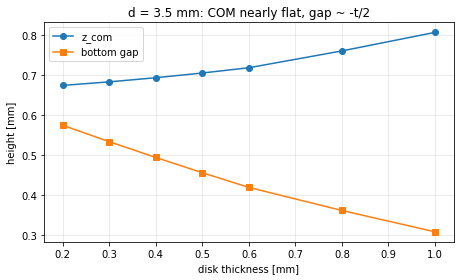

Winged rotor (+12% dead mass, no chi): z_com 0.706 -> 0.681 mm
chi_z = -360e-6: z_com = 0.668 mm
chi_z = -540e-6: z_com = 0.743 mm
Br -5% both magnets: z_com = 0.681 mm
inner magnet 0.2 mm below flush: z_com = 0.618 mm


In [5]:
# thickness sweep + dead mass + parameter sensitivity
ts = np.array([0.2,0.3,0.4,0.5,0.6,0.8,1.0])*1e-3
zs = np.array([z_eq(3.5e-3, ti)[0] for ti in ts])
fig, ax = plt.subplots(figsize=(6.5,4))
ax.plot(ts*1e3, zs*1e3, 'o-', label='z_com')
ax.plot(ts*1e3, (zs-ts/2)*1e3, 's-', label='bottom gap')
ax.set_xlabel('disk thickness [mm]'); ax.set_ylabel('height [mm]')
ax.set_title('d = 3.5 mm: COM nearly flat, gap ~ -t/2')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('levitation_vs_thickness.png', dpi=140); plt.show()

ze0 = z_eq(3.5e-3, 0.5e-3)[0]
ze_w = z_eq(3.5e-3, 0.5e-3, extra_m_frac=0.12)[0]
print(f"Winged rotor (+12% dead mass, no chi): z_com {ze0*1e3:.3f} -> {ze_w*1e3:.3f} mm")
for cz in (0.8*CHI_Z, 1.2*CHI_Z):
    print(f"chi_z = {cz*1e6:.0f}e-6: z_com = {z_eq(3.5e-3,0.5e-3,chi_z=cz)[0]*1e3:.3f} mm")
BRlo, BZlo = build_field(br_in=1.32*0.95, br_out=1.48*0.95)
print(f"Br -5% both magnets: z_com = {z_eq(3.5e-3,0.5e-3,Br=BRlo,Bz=BZlo)[0]*1e3:.3f} mm")
BRoff, BZoff = build_field(z_inner_offset=-0.2e-3)
print(f"inner magnet 0.2 mm below flush: z_com = {z_eq(3.5e-3,0.5e-3,Br=BRoff,Bz=BZoff)[0]*1e3:.3f} mm")

## Notes / extensions
- Height is size/mass-independent because lift and weight both scale with volume;
  only U/V matters. Diameter controls *lateral stability* instead (must straddle the flux boundary).
- Bottom gap decreases ~t/2 with thickness (field decays with z; thicker disk's COM must sit
  where the volume-average still balances).
- Knobs to refine: countersink geometry of the ring bore, actual Br of both magnets
  (grade tolerance ~5%), chi_z of this graphite sheet, inner-magnet axial position (assembly!).
- TODO: tilt potential U(theta) for wobble stiffness; winged-rotor footprint instead of disk;
  trap-mode frequencies vs measurement (levitation-mode-coupling systematic in Dave's doc).